<a href="https://colab.research.google.com/github/abdulrasheedmd2005/Week2-DataScience-Tasks/blob/main/Dashboard_prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install streamlit

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score
import pickle

In [3]:
from google.colab import files
uploaded = files.upload()

Saving Student_Performance_Dataset.csv to Student_Performance_Dataset (1).csv


In [4]:
df = pd.read_csv('Student_Performance_Dataset.csv')

In [5]:
df.head()

,Student_ID,Age,Gender,Class,Study_Hours_Per_Day,Attendance_Percentage,Parental_Education,Internet_Access,Extracurricular_Activities,Math_Score,Science_Score,English_Score,Previous_Year_Score,Final_Percentage,Performance_Level,Pass_Fail
0,S0001,15,Male,12,1.0,65,Postgraduate,No,No,40,39,72,81,50.33,Average,Pass
1,S0002,19,Female,9,1.6,58,Graduate,No,Yes,80,44,35,47,53.00,Average,Pass
2,S0003,14,Female,12,3.6,64,High School,Yes,Yes,83,73,59,58,71.67,Good,Pass
3,S0004,18,Female,9,5.5,68,Postgraduate,Yes,No,68,48,77,54,64.33,Average,Pass
4,S0005,14,Male,10,5.0,80,High School,Yes,No,41,46,36,68,41.00,Poor,Fail


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 16 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Student_ID                  5000 non-null   object 
 1   Age                         5000 non-null   int64  
 2   Gender                      5000 non-null   object 
 3   Class                       5000 non-null   int64  
 4   Study_Hours_Per_Day         5000 non-null   float64
 5   Attendance_Percentage       5000 non-null   int64  
 6   Parental_Education          5000 non-null   object 
 7   Internet_Access             5000 non-null   object 
 8   Extracurricular_Activities  5000 non-null   object 
 9   Math_Score                  5000 non-null   int64  
 10  Science_Score               5000 non-null   int64  
 11  English_Score               5000 non-null   int64  
 12  Previous_Year_Score         5000 non-null   int64  
 13  Final_Percentage            5000 

In [7]:
df.isnull().sum()

,0
Student_ID,0
Age,0
Gender,0
Class,0
Study_Hours_Per_Day,0
Attendance_Percentage,0
Parental_Education,0
Internet_Access,0
Extracurricular_Activities,0
Math_Score,0


In [8]:
df.dropna(inplace=True)

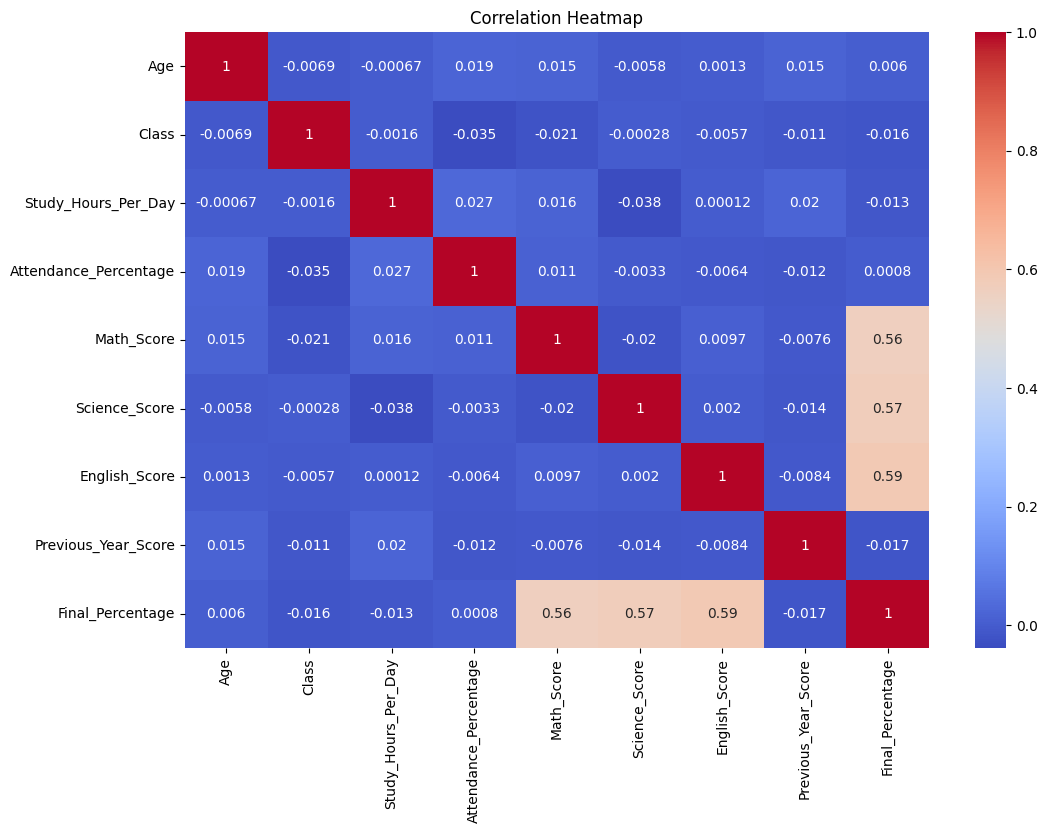

In [9]:
plt.figure(figsize=(12,8))
numeric_df = df.select_dtypes(include=['number'])
sns.heatmap(numeric_df.corr(),annot=True,cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

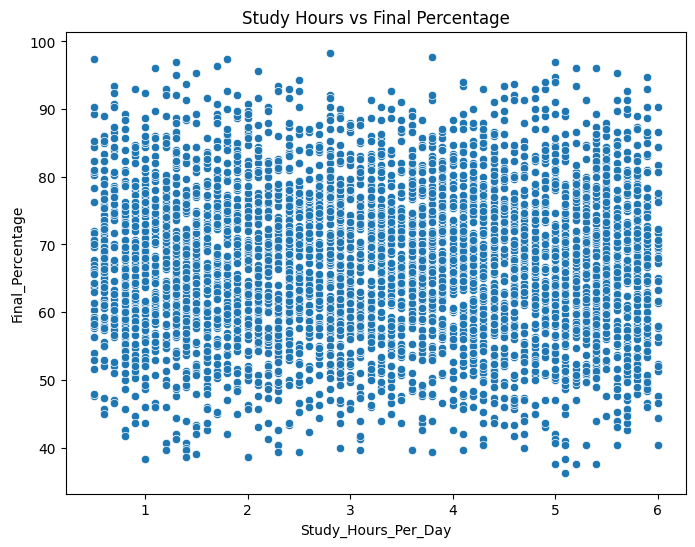

In [10]:
plt.figure(figsize=(8,6))
sns.scatterplot(x='Study_Hours_Per_Day',y='Final_Percentage',data=df)
plt.title('Study Hours vs Final Percentage')
plt.show()

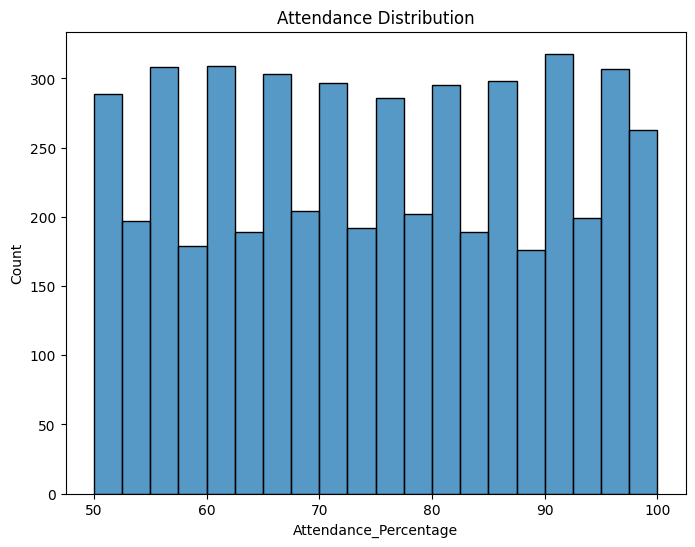

In [11]:
plt.figure(figsize=(8,6))
sns.histplot(df['Attendance_Percentage'],bins=20)
plt.title('Attendance Distribution')
plt.show()

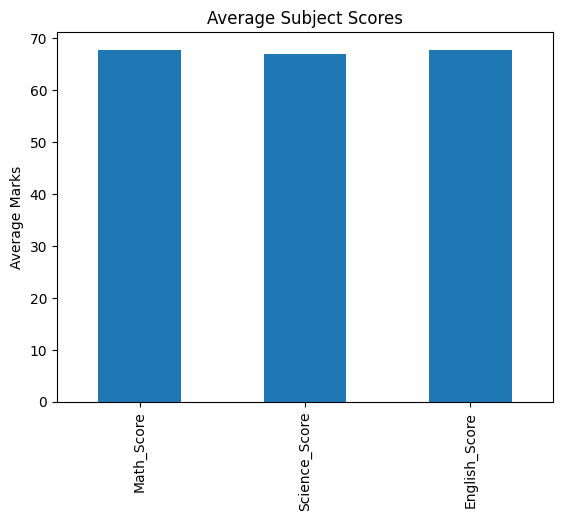

In [12]:
subjects = ['Math_Score','Science_Score','English_Score']
df[subjects].mean().plot(kind='bar')
plt.title('Average Subject Scores')
plt.ylabel('Average Marks')
plt.show()

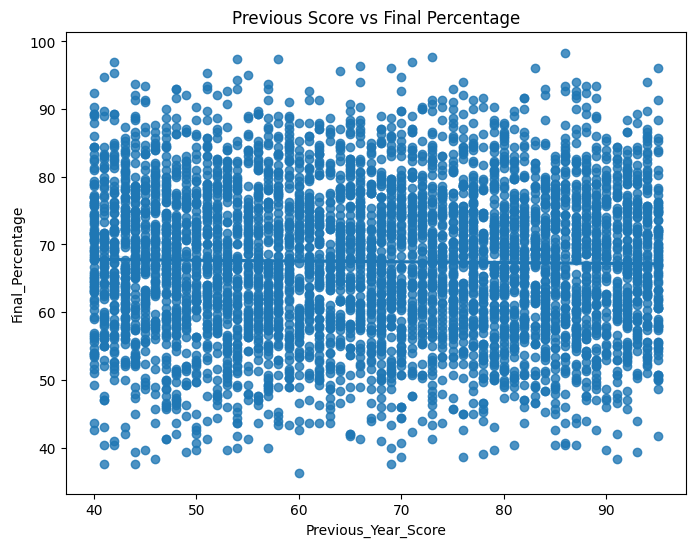

In [13]:
plt.figure(figsize=(8,6))
sns.regplot(x='Previous_Year_Score',y='Final_Percentage',data=df)
plt.title('Previous Score vs Final Percentage')
plt.show()

In [14]:
X = df[['Age','Class','Study_Hours_Per_Day','Attendance_Percentage','Math_Score','Science_Score','English_Score','Previous_Year_Score']]

y = df['Final_Percentage']

In [15]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [16]:
model = LinearRegression()

In [17]:
model.fit(X_train, y_train)

LinearRegression()

In [18]:
y_pred = model.predict(X_test)

In [19]:
print("Mean Absolute Error:",mean_absolute_error(y_test, y_pred))

print("R2 Score:",r2_score(y_test, y_pred))

Mean Absolute Error: 0.0022703030713948423
R2 Score: 0.9999999371414736


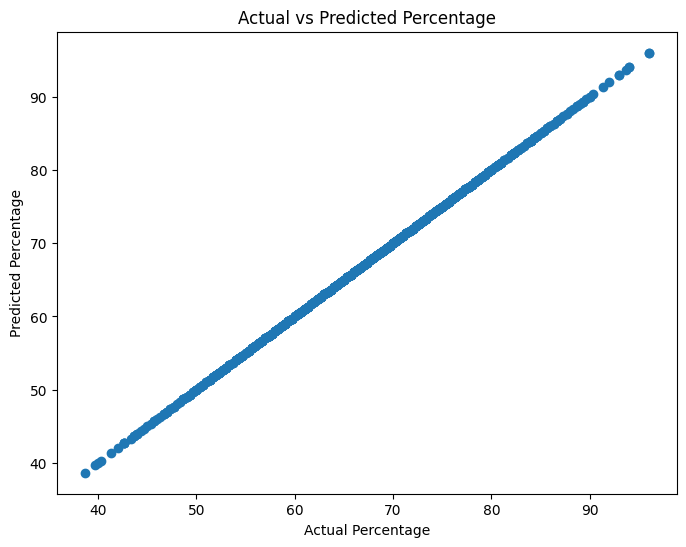

In [20]:
plt.figure(figsize=(8,6))
plt.scatter(y_test, y_pred)
plt.xlabel('Actual Percentage')
plt.ylabel('Predicted Percentage')
plt.title('Actual vs Predicted Percentage')
plt.show()

In [27]:
pickle.dump(model,open('model.pkl', 'wb'))

In [28]:
from google.colab import files
files.download('model.pkl')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>